# 03_Fast_Modeling_Local.ipynb

## Part 1: Setup and Data Loading
This notebook is designed for local analysis (Jupyter/VSCode) using a relative path to the pre-processed results.

In [4]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
import os

# 1. Configuration & Hardcoded Edges
CORE_ASPECTS = [
    'ingredients', 'packaging', 'price/value', 'service/shipping',
    'smell/fragrance', 'effectiveness/results', 'texture/consistency'
]

NAME_MAP = {
    'ingredients': 'ingredients',
    'packaging': 'packaging',
    'price/value': 'price_value',
    'service/shipping': 'service_shipping',
    'smell/fragrance': 'smell_fragrance',
    'effectiveness/results': 'effectiveness_results',
    'texture/consistency': 'texture_consistency'
}

GLASSO_EDGES = [
    ('smell_fragrance', 'texture_consistency'), ('smell_fragrance', 'packaging'),
    ('smell_fragrance', 'ingredients'), ('price_value', 'packaging'),
    ('price_value', 'ingredients'), ('price_value', 'effectiveness_results'),
    ('price_value', 'service_shipping'), ('texture_consistency', 'packaging'),
    ('texture_consistency', 'ingredients'), ('texture_consistency', 'effectiveness_results'),
    ('packaging', 'ingredients'), ('packaging', 'effectiveness_results'),
    ('packaging', 'service_shipping'), ('ingredients', 'effectiveness_results'),
    ('ingredients', 'service_shipping')
]

# 2. Load Local Data
data_path = '../data/Seminar_Amazon_Results_FULL.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"✅ Local data loaded: {len(df)} rows.")
else:
    print(f"❌ Error: File not found at {data_path}. Please ensure the CSV is in the './data/' folder.")

✅ Local data loaded: 701528 rows.


## Part 2: Critical Data Parsing and Pivoting

In [5]:
def process_saved_results(df):
    """Parses stringified lists, pivots, and mean-centers features."""
    
    # 1. CRITICAL: Parse stringified lists of tuples
    print("Parsing aspect_sentiments column...")
    df['aspect_sentiments'] = df['aspect_sentiments'].apply(ast.literal_eval)
    
    # 2. Pivot
    print("Pivoting and averaging duplicate mentions...")
    exploded = df[['aspect_sentiments']].explode('aspect_sentiments')
    exploded = exploded.dropna(subset=['aspect_sentiments'])
    aspect_sent = pd.DataFrame(exploded['aspect_sentiments'].tolist(), index=exploded.index)
    aspect_sent.columns = ['aspect', 'sentiment']
    
    # Group by index and aspect, take the MEAN of sentiments (as requested)
    pivoted = aspect_sent.groupby([aspect_sent.index, 'aspect'])['sentiment'].mean().unstack(fill_value=0.0)
    
    # 3. Rename and Ensure all aspects are present
    final_aspects = []
    for raw_name in CORE_ASPECTS:
        clean_name = NAME_MAP.get(raw_name, raw_name.replace('/', '_').replace(' ', '_'))
        if raw_name in pivoted.columns:
            pivoted = pivoted.rename(columns={raw_name: clean_name})
        else:
            if clean_name not in pivoted.columns:
                pivoted[clean_name] = 0.0
        final_aspects.append(clean_name)
    
    # 4. Merge with original data for rating
    data = pivoted.join(df[['rating']])
    data = data.dropna(subset=['rating'])
    
    # 5. Sparsity filter
    data = data[(data[final_aspects] != 0).any(axis=1)].copy()
    
    # 6. Mean centering
    print("Mean-centering features...")
    for col in final_aspects:
        data[col] = data[col] - data[col].mean()
        
    return data, final_aspects

model_data, base_features = process_saved_results(df)

Parsing aspect_sentiments column...
Pivoting and averaging duplicate mentions...
Mean-centering features...


## Part 3: Statistical Modeling and Evaluation


SCIENTIFIC MODEL COMPARISON (WITH CLIPPING)

BASELINE:
Original -> R2: 0.3353 | Adj R2: 0.3353 | RMSE: 1.2143 | BIC: 1039391.31
Clipped  -> R2: 0.3526 | Adj R2: 0.3525 | RMSE: 1.1985

GLASSO NETWORK:
Original -> R2: 0.3497 | Adj R2: 0.3496 | RMSE: 1.2011 | BIC: 1032536.33
Clipped  -> R2: 0.3568 | Adj R2: 0.3567 | RMSE: 1.1945

KITCHEN SINK:
Original -> R2: 0.3506 | Adj R2: 0.3506 | RMSE: 1.2002 | BIC: 1032123.15
Clipped  -> R2: 0.3575 | Adj R2: 0.3575 | RMSE: 1.1939


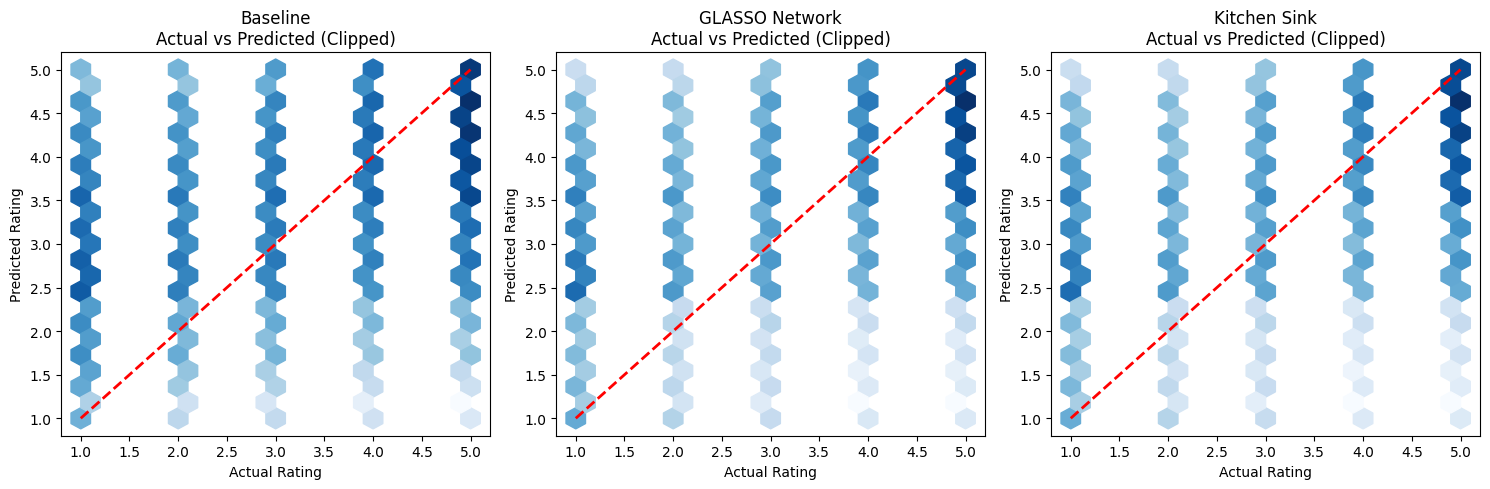

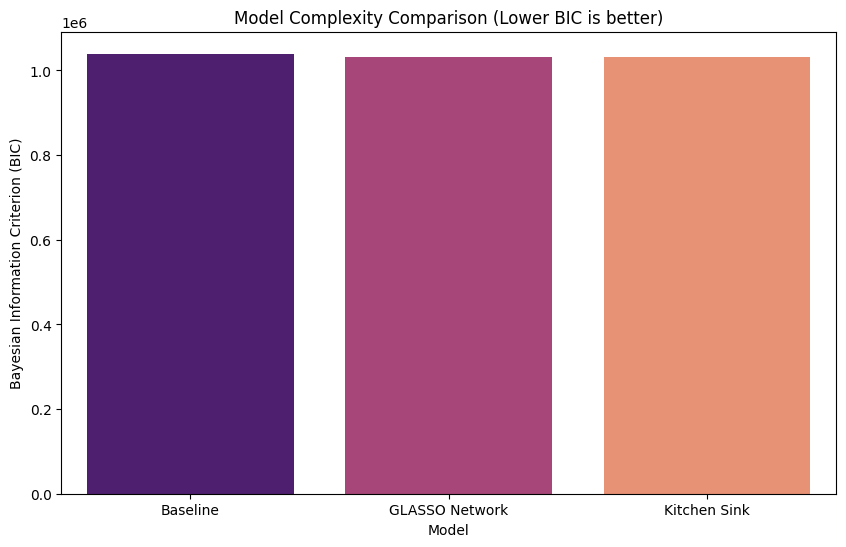

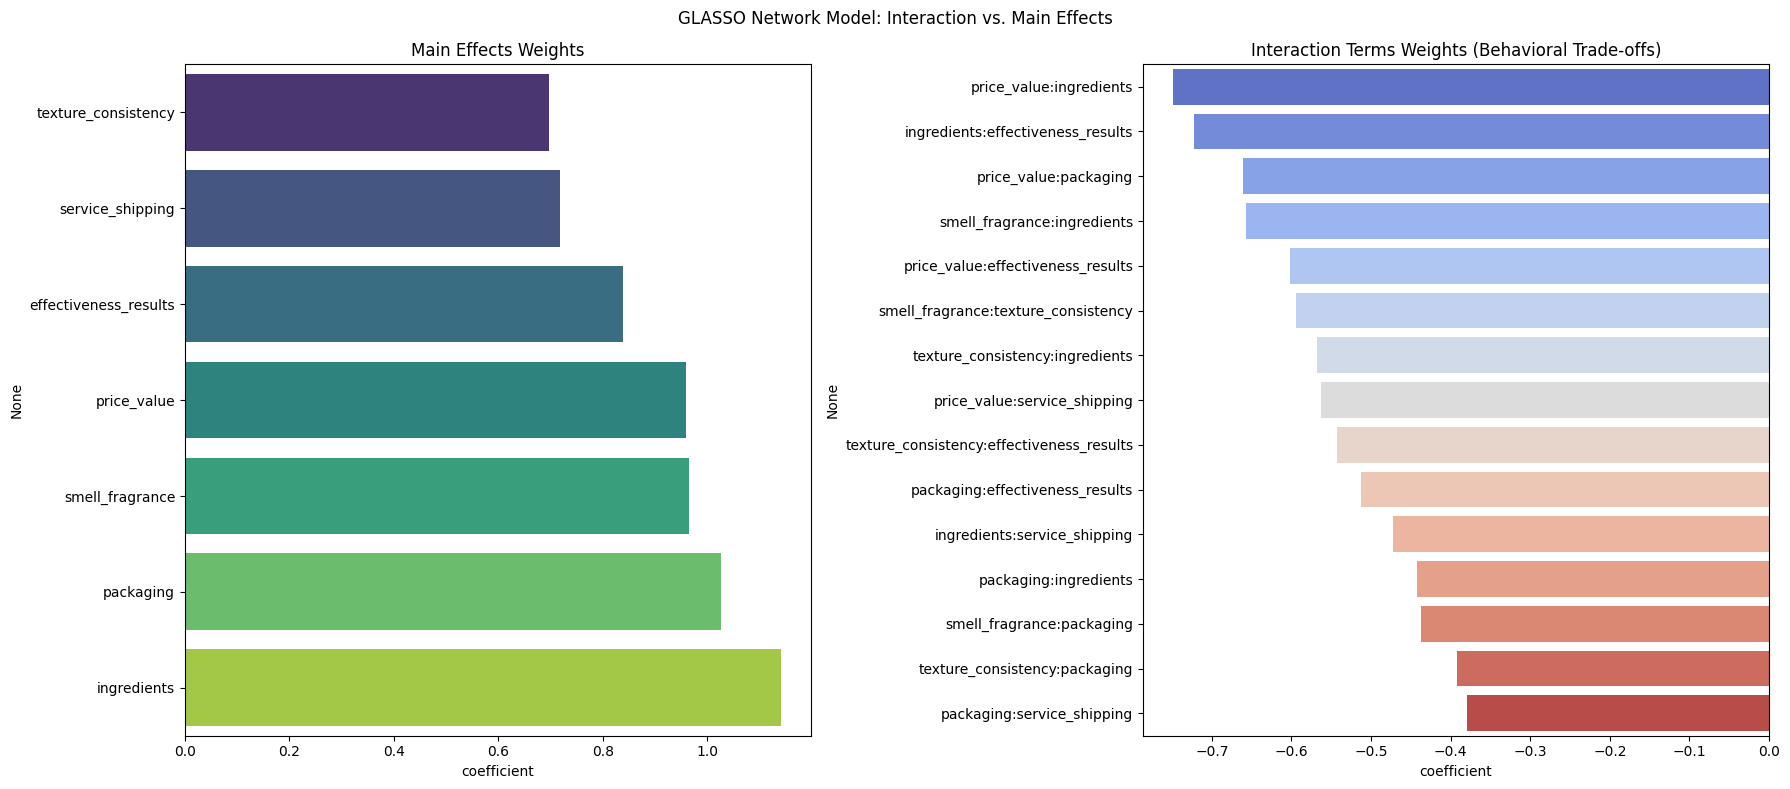

In [6]:
# 1. Define Formulas
baseline_formula = "rating ~ " + " + ".join(base_features)

glasso_interactions = [f"{u} * {v}" for u, v in GLASSO_EDGES]
glasso_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(glasso_interactions)

all_interactions = []
for i in range(len(base_features)):
    for j in range(i + 1, len(base_features)):
        all_interactions.append(f"{base_features[i]} * {base_features[j]}")
kitchen_sink_formula = "rating ~ " + " + ".join(base_features) + " + " + " + ".join(all_interactions)

# 2. Fit Models
model_baseline = smf.ols(baseline_formula, data=model_data).fit()
model_glasso = smf.ols(glasso_formula, data=model_data).fit()
model_kitchen = smf.ols(kitchen_sink_formula, data=model_data).fit()

# 3. Scientific Comparison & Clipping
print("\n" + "="*50)
print("SCIENTIFIC MODEL COMPARISON (WITH CLIPPING)")
print("="*50)

y_true = model_data['rating']
models = [('Baseline', model_baseline), ('GLASSO Network', model_glasso), ('Kitchen Sink', model_kitchen)]
results = []

for name, model in models:
    y_pred = model.predict(model_data)
    y_pred_clipped = np.clip(y_pred, 1, 5)
    
    n = len(model_data)
    p = len(model.params) - 1
    
    # Original Metrics
    r2_orig = model.rsquared
    adj_r2_orig = model.rsquared_adj
    rmse_orig = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Clipped Metrics
    r2_clip = r2_score(y_true, y_pred_clipped)
    adj_r2_clip = 1 - (1 - r2_clip) * (n - 1) / (n - p - 1)
    rmse_clip = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
    
    results.append({
        'Model': name,
        'R2_Orig': r2_orig,
        'Adj_R2_Orig': adj_r2_orig,
        'RMSE_Orig': rmse_orig,
        'R2_Clipped': r2_clip,
        'Adj_R2_Clipped': adj_r2_clip,
        'RMSE_Clipped': rmse_clip,
        'BIC': model.bic,
        'Params': len(model.params)
    })
    
    print(f"\n{name.upper()}:")
    print(f"Original -> R2: {r2_orig:.4f} | Adj R2: {adj_r2_orig:.4f} | RMSE: {rmse_orig:.4f} | BIC: {model.bic:.2f}")
    print(f"Clipped  -> R2: {r2_clip:.4f} | Adj R2: {adj_r2_clip:.4f} | RMSE: {rmse_clip:.4f}")

# 4. Visualization: Actual vs Predicted (Clipped)
plt.figure(figsize=(15, 5))
for i, (name, model) in enumerate(models):
    y_pred_clipped = np.clip(model.predict(model_data), 1, 5)
    plt.subplot(1, 3, i+1)
    plt.hexbin(y_true, y_pred_clipped, gridsize=20, cmap='Blues', bins='log')
    plt.plot([1, 5], [1, 5], '--r', lw=2)
    plt.title(f'{name}\nActual vs Predicted (Clipped)')
    plt.xlabel('Actual Rating')
    plt.ylabel('Predicted Rating')
plt.tight_layout()
plt.show()

# 5. Model Complexity Comparison
results_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='BIC', data=results_df, palette='magma', hue='Model', legend=False)
plt.title('Model Complexity Comparison (Lower BIC is better)')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.show()

# 6. Coefficients Plot for GLASSO Model
coef_df = model_glasso.params.drop('Intercept')
interactions = coef_df[coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')
main_effects = coef_df[~coef_df.index.str.contains(':')].sort_values().to_frame('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Main Effects
if not main_effects.empty:
    sns.barplot(x='coefficient', y=main_effects.index, data=main_effects, palette='viridis', hue=main_effects.index, legend=False, ax=axes[0])
axes[0].set_title('Main Effects Weights')

# Interaction Terms
if not interactions.empty:
    sns.barplot(x='coefficient', y=interactions.index, data=interactions, palette='coolwarm', hue=interactions.index, legend=False, ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'No Interaction Terms Found', ha='center', va='center')
axes[1].set_title('Interaction Terms Weights (Behavioral Trade-offs)')

plt.suptitle('GLASSO Network Model: Interaction vs. Main Effects')
plt.tight_layout()
plt.show()